# Creating Spatiotemporal Anomaly Maps using PACE Level 3 Data
Included in this notebook:
> **Chlorophyll-a (CHL)**</p>
> **Particulate Organic Carbon:Chlorophyll-a (POC:CHL)**</p>
> **Diffuse Attenutation at 490 nm:Chlorophyll-a (Kd490:CHL)**</p>
***

In [1]:
!pip install cmocean

  Using cached cmocean-4.0.3-py3-none-any.whl.metadata (4.2 kB)
Using cached cmocean-4.0.3-py3-none-any.whl (421 kB)


In [2]:
# First, import all necessary libraries, modules, and packages. Earthaccess is essential since we will need this to pull PACE data for our analyses
import earthaccess
import xarray as xr
from xarray.backends.api import open_datatree
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import numpy as np
import matplotlib.animation as animation
import os
from PIL import Image, ImageEnhance
import cmocean
import scipy.stats as scipy
import pandas as pd
import matplotlib.patches as mpatches

In [3]:
# enter your login information for NASA Earthdata
auth = earthaccess.login(persist=True)
# search the dataset for an instrument you want to work with. In this case, we are going to start with the Ocean Color Instrument (OCI)
results = earthaccess.search_datasets(instrument="oci")
# for an index (item) in results (the dataset), print the associated products (the summary)
    # in this, you will see the products available from your selected instrument
for item in results:
    summary = item.summary()
    print(summary["short-name"])

PACE_OCI_L1B_SCI
PACE_OCI_L2_AOP
PACE_OCI_L2_BGC_NRT
PACE_OCI_L0_SCI
PACE_OCI_L1A_SCI
PACE_OCI_L1C_SCI
PACE_OCI_L2_AOP_NRT
PACE_OCI_L2_BGC
PACE_OCI_L2_CLOUD
PACE_OCI_L2_CLOUD_MASK
PACE_OCI_L2_CLOUD_MASK_NRT
PACE_OCI_L2_CLOUD_NRT
PACE_OCI_L2_IOP
PACE_OCI_L2_IOP_NRT
PACE_OCI_L2_LANDVI
PACE_OCI_L2_LANDVI_NRT
PACE_OCI_L2_PAR
PACE_OCI_L2_PAR_NRT
PACE_OCI_L2_SFREFL
PACE_OCI_L2_SFREFL_NRT
PACE_OCI_L3B_AVW
PACE_OCI_L3B_AVW_NRT
PACE_OCI_L3B_CARBON
PACE_OCI_L3B_CARBON_NRT
PACE_OCI_L3B_CHL
PACE_OCI_L3B_CHL_NRT
PACE_OCI_L3B_FLH
PACE_OCI_L3B_FLH_NRT
PACE_OCI_L3B_IOP
PACE_OCI_L3B_IOP_NRT
PACE_OCI_L3B_KD
PACE_OCI_L3B_KD_NRT
PACE_OCI_L3B_LANDVI
PACE_OCI_L3B_LANDVI_NRT
PACE_OCI_L3B_PAR
PACE_OCI_L3B_PAR_NRT
PACE_OCI_L3B_POC
PACE_OCI_L3B_POC_NRT
PACE_OCI_L3B_RRS
PACE_OCI_L3B_RRS_NRT
PACE_OCI_L3B_SFREFL
PACE_OCI_L3B_SFREFL_NRT
PACE_OCI_L3M_AVW
PACE_OCI_L3M_AVW_NRT
PACE_OCI_L3M_CARBON
PACE_OCI_L3M_CARBON_NRT
PACE_OCI_L3M_CHL
PACE_OCI_L3M_CHL_NRT
PACE_OCI_L3M_CLOUD
PACE_OCI_L3M_CLOUD_NRT
PACE_OCI_L3M_FLH
PA

# CHLOROPHYLL-A (CHL)

In [4]:
## Anyway, let's proceed. Alter the time span (tspan) to your frame of interest
tspan = ("2024-12-31", "2025-06-30") # if you just want one day, just do the tspan with the same begin and end date
lon_min, lon_max = -128.045, -120.517 #og
lat_min, lat_max = 25.179, 31.164 #og 
bbox = (lon_min, lat_min, lon_max, lat_max)
shortname = "PACE_OCI_L3M_CHL"
clouds = (0,20) #change to (0,100) to see all satellite images (might have clear spot over spot of interest, even if cloudy)

In [43]:
results = earthaccess.search_data(
    short_name=shortname,
    granule_name= '*.8D*4km*',#"*DAY*RRS*4km*.nc", #'*.D*4km*',   #Kd:"*4km*.nc",  #*.8D*4km*", #"*DAY*4km*.nc*" #"*AOP*.nc*"
    temporal=tspan,
    bounding_box=bbox
)
paths = earthaccess.open(results)

QUEUEING TASKS | :   0%|          | 0/16 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/16 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/16 [00:00<?, ?it/s]

In [44]:
index=1 # set the day you want to look at
datatree = open_datatree(paths[index]) # open the dataset based on that day
dataset = xr.merge(datatree.to_dict().values()) # merge the datatree to a dictionary format
dataset = dataset.set_coords(("lon", "lat")) # set the map based on lat and lon
dataset
# NIR BANDS (780 nm to 2500 nm): 779 nm, 784 nm, 789 nm, ... 2258 nm # see PACE_OCI_L3M_SFREFL for them

<xarray.Dataset> Size: 149MB
Dimensions:  (lat: 4320, lon: 8640, rgb: 3, eightbitcolor: 256)
Coordinates:
  * lat      (lat) float32 17kB 89.98 89.94 89.9 89.85 ... -89.9 -89.94 -89.98
  * lon      (lon) float32 35kB -180.0 -179.9 -179.9 ... 179.9 179.9 180.0
Dimensions without coordinates: rgb, eightbitcolor
Data variables:
    chlor_a  (lat, lon) float32 149MB ...
    palette  (rgb, eightbitcolor) uint8 768B ...
Attributes: (12/64)
    product_name:                      PACE_OCI.20250101_20250108.L3m.8D.CHL....
    instrument:                        OCI
    title:                             OCI Level-3 Standard Mapped Image
    project:                           Ocean Biology Processing Group (NASA/G...
    platform:                          PACE
    source:                            satellite observations from OCI-PACE
    ...                                ...
    identifier_product_doi:            10.5067/PACE/OCI/L3M/CHL/3.0
    keywords:                          Earth Science > Oceans > Ocean Chemist...
    keywords_vocabulary:               NASA Global Change Master Directory (G...
    data_bins:                         11134198
    data_minimum:                      0.004042408
    data_maximum:                      98.92007

In [49]:
# set the day you want to look at
index = 4
# open the dataset based on that day
datatree = open_datatree(paths[index]) 
# merge the datatree to a dictionary format
d2 = xr.merge(datatree.to_dict().values()) 
# set the map based on lat and lon
d2 = d2.set_coords(("lon", "lat")) 
d2

<xarray.Dataset> Size: 149MB
Dimensions:  (lat: 4320, lon: 8640, rgb: 3, eightbitcolor: 256)
Coordinates:
  * lat      (lat) float32 17kB 89.98 89.94 89.9 89.85 ... -89.9 -89.94 -89.98
  * lon      (lon) float32 35kB -180.0 -179.9 -179.9 ... 179.9 179.9 180.0
Dimensions without coordinates: rgb, eightbitcolor
Data variables:
    chlor_a  (lat, lon) float32 149MB ...
    palette  (rgb, eightbitcolor) uint8 768B ...
Attributes: (12/64)
    product_name:                      PACE_OCI.20250125_20250201.L3m.8D.CHL....
    instrument:                        OCI
    title:                             OCI Level-3 Standard Mapped Image
    project:                           Ocean Biology Processing Group (NASA/G...
    platform:                          PACE
    source:                            satellite observations from OCI-PACE
    ...                                ...
    identifier_product_doi:            10.5067/PACE/OCI/L3M/CHL/3.0
    keywords:                          Earth Science > Oceans > Ocean Chemist...
    keywords_vocabulary:               NASA Global Change Master Directory (G...
    data_bins:                         13305653
    data_minimum:                      0.0009999999
    data_maximum:                      97.24187

In [50]:
ds = d2['chlor_a'] - dataset['chlor_a']
#ds = (d2['Kd'].sel(wavelength=490)) - (dataset['Kd'].sel(wavelength=490))
#ds = d2['chlor_a']
ds

<xarray.DataArray 'chlor_a' (lat: 4320, lon: 8640)> Size: 149MB
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]], dtype=float32)
Coordinates:
  * lat      (lat) float32 17kB 89.98 89.94 89.9 89.85 ... -89.9 -89.94 -89.98
  * lon      (lon) float32 35kB -180.0 -179.9 -179.9 ... 179.9 179.9 180.0

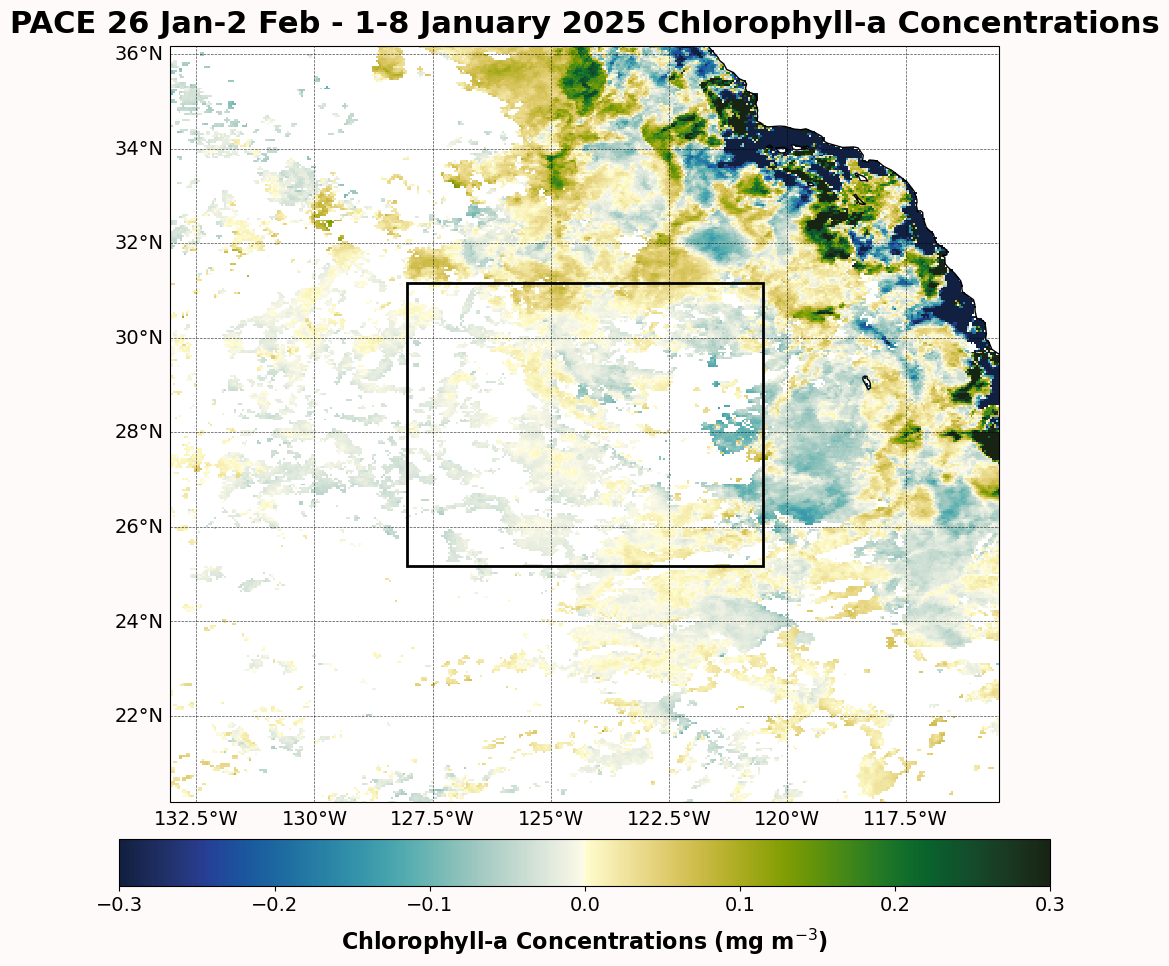

In [51]:
# plot the data
fig = plt.figure(figsize=(10,10), facecolor = 'snow')
ax = plt.axes(projection=ccrs.PlateCarree())

#mesh = dataset['chlor_a'].plot(ax=ax, cmap='cmo.algae', vmin=0, vmax=0.5, transform=ccrs.PlateCarree(), add_colorbar=False)
mesh = ds.plot(ax=ax, cmap='cmo.delta', vmin=-0.3, vmax=0.3, transform=ccrs.PlateCarree(), add_colorbar=False)

lon_min, lon_max = -128.045, -120.517 #og
lat_min, lat_max = 25.179, 31.164 #og
width = lon_max - lon_min
height = lat_max - lat_min
ax.add_patch(mpatches.Rectangle(xy=[lon_min, lat_min], width=width, height=height, facecolor='none', edgecolor='k', linewidth = 2, zorder = 6, transform=ccrs.PlateCarree()))

# add coastline and set limits of plot
ax.coastlines()
ax.set_ylim([lat_min-5, lat_max+5])
ax.set_xlim([lon_min-5, lon_max+5])

# set the colorbar
cbar = fig.colorbar(mesh, ax=ax, orientation='horizontal', shrink = 1, pad=0.04)  
cbar.set_label('Chlorophyll-a Concentrations (mg m$^{-3}$)', fontsize = 16, fontweight = 'bold', labelpad=8)
cbar.ax.tick_params(labelsize=14)

# edit the gridlines
gl = ax.gridlines(crs = ccrs.PlateCarree(), draw_labels = True, color = 'k', alpha=0.7, linewidth=0.5, linestyle='--')
gl.right_labels = False  
gl.top_labels = False   
gl.xlabel_style = {'size':14}
gl.ylabel_style = {'size':14}

# set the title and save the figure
ax.set_title('PACE 26 Jan-2 Feb - 1-8 January 2025 Chlorophyll-a Concentrations', fontsize=22, fontweight = 'bold', pad = 10)
plt.tight_layout()
plt.savefig('/home/jovyan/Desktop/figures/PACE/maps/Chl-a 26Jan-2Feb -- 1-8 Jan.png', bbox_inches = 'tight', dpi=300)

# POC:CHL RATIOS

In [29]:
## Anyway, let's proceed. Alter the time span (tspan) to your frame of interest
tspan = ("2024-12-31", "2025-06-30") # if you just want one day, just do the tspan with the same begin and end date
lon_min, lon_max = -128.045, -120.517 #og
lat_min, lat_max = 25.179, 31.164 #og 
bbox = (lon_min, lat_min, lon_max, lat_max)
shortname_kd = "PACE_OCI_L3M_Kd"
shortname_poc = "PACE_OCI_L3M_POC"
shortname_CHL = "PACE_OCI_L3M_CHL"
clouds = (0,20) #change to (0,100) to see all satellite images (might have clear spot over spot of interest, even if cloudy)

In [30]:
# search for data and open results for poc
results_poc = earthaccess.search_data(
    short_name=shortname_poc,
    granule_name= '*.8D*4km*',#"*DAY*RRS*4km*.nc", #'*.D*4km*',   #Kd:"*4km*.nc",  #*.8D*4km*", #"*DAY*4km*.nc*" #"*AOP*.nc*"
    temporal=tspan,
    bounding_box=bbox
)
paths_poc = earthaccess.open(results_poc)

# search for data and open results for chla
results_CHL = earthaccess.search_data(
    short_name=shortname_CHL,
    granule_name= '*.8D*4km*',#"*DAY*RRS*4km*.nc", #'*.D*4km*',   #Kd:"*4km*.nc",  #*.8D*4km*", #"*DAY*4km*.nc*" #"*AOP*.nc*"
    temporal=tspan,
    bounding_box=bbox
)
paths_CHL = earthaccess.open(results_CHL)

QUEUEING TASKS | :   0%|          | 0/16 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/16 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/16 [00:00<?, ?it/s]

QUEUEING TASKS | :   0%|          | 0/16 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/16 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/16 [00:00<?, ?it/s]

## Period 1 -- first TOI

In [31]:
# poc
index=1 #1-9 # set the day you want to look at
datatree_poc = open_datatree(paths_poc[index]) # open the dataset based on that day
dataset_poc = xr.merge(datatree_poc.to_dict().values()) # merge the datatree to a dictionary format
dataset_poc = dataset_poc.set_coords(("lon", "lat")) # set the map based on lat and lon

# CHL
index=1 #1-9 # set the day you want to look at
datatree_CHL = open_datatree(paths_CHL[index]) # open the dataset based on that day
dataset_CHL = xr.merge(datatree_CHL.to_dict().values()) # merge the datatree to a dictionary format
dataset_CHL = dataset_CHL.set_coords(("lon", "lat")) # set the map based on lat and lon
dataset_CHL

<xarray.Dataset> Size: 149MB
Dimensions:  (lat: 4320, lon: 8640, rgb: 3, eightbitcolor: 256)
Coordinates:
  * lat      (lat) float32 17kB 89.98 89.94 89.9 89.85 ... -89.9 -89.94 -89.98
  * lon      (lon) float32 35kB -180.0 -179.9 -179.9 ... 179.9 179.9 180.0
Dimensions without coordinates: rgb, eightbitcolor
Data variables:
    chlor_a  (lat, lon) float32 149MB ...
    palette  (rgb, eightbitcolor) uint8 768B ...
Attributes: (12/64)
    product_name:                      PACE_OCI.20250101_20250108.L3m.8D.CHL....
    instrument:                        OCI
    title:                             OCI Level-3 Standard Mapped Image
    project:                           Ocean Biology Processing Group (NASA/G...
    platform:                          PACE
    source:                            satellite observations from OCI-PACE
    ...                                ...
    identifier_product_doi:            10.5067/PACE/OCI/L3M/CHL/3.0
    keywords:                          Earth Science > Oceans > Ocean Chemist...
    keywords_vocabulary:               NASA Global Change Master Directory (G...
    data_bins:                         11134198
    data_minimum:                      0.004042408
    data_maximum:                      98.92007

In [32]:
# take ratio of the day (ratio1)
ds_ratio_1 = dataset_poc['poc']/dataset_CHL['chlor_a']
ds_ratio_1

<xarray.DataArray (lat: 4320, lon: 8640)> Size: 149MB
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]], dtype=float32)
Coordinates:
  * lat      (lat) float32 17kB 89.98 89.94 89.9 89.85 ... -89.9 -89.94 -89.98
  * lon      (lon) float32 35kB -180.0 -179.9 -179.9 ... 179.9 179.9 180.0

## Period 2 -- second TOI

In [33]:
# repeat process again for the second period
# poc
index=3 #1-9 # set the day you want to look at
datatree_poc = open_datatree(paths_poc[index]) # open the dataset based on that day
dataset_poc = xr.merge(datatree_poc.to_dict().values()) # merge the datatree to a dictionary format
dataset_poc = dataset_poc.set_coords(("lon", "lat")) # set the map based on lat and lon

# CHL
index=3 #17=13 # set the day you want to look at
datatree_CHL = open_datatree(paths_CHL[index]) # open the dataset based on that day
dataset_CHL = xr.merge(datatree_CHL.to_dict().values()) # merge the datatree to a dictionary format
dataset_CHL = dataset_CHL.set_coords(("lon", "lat")) # set the map based on lat and lon
dataset_CHL

<xarray.Dataset> Size: 149MB
Dimensions:  (lat: 4320, lon: 8640, rgb: 3, eightbitcolor: 256)
Coordinates:
  * lat      (lat) float32 17kB 89.98 89.94 89.9 89.85 ... -89.9 -89.94 -89.98
  * lon      (lon) float32 35kB -180.0 -179.9 -179.9 ... 179.9 179.9 180.0
Dimensions without coordinates: rgb, eightbitcolor
Data variables:
    chlor_a  (lat, lon) float32 149MB ...
    palette  (rgb, eightbitcolor) uint8 768B ...
Attributes: (12/64)
    product_name:                      PACE_OCI.20250117_20250124.L3m.8D.CHL....
    instrument:                        OCI
    title:                             OCI Level-3 Standard Mapped Image
    project:                           Ocean Biology Processing Group (NASA/G...
    platform:                          PACE
    source:                            satellite observations from OCI-PACE
    ...                                ...
    identifier_product_doi:            10.5067/PACE/OCI/L3M/CHL/3.0
    keywords:                          Earth Science > Oceans > Ocean Chemist...
    keywords_vocabulary:               NASA Global Change Master Directory (G...
    data_bins:                         13762378
    data_minimum:                      0.001
    data_maximum:                      97.09501

In [34]:
# take ratio of the day (ratio2)
ds_ratio_2 = dataset_poc['poc']/dataset_CHL['chlor_a']
ds_ratio_2

<xarray.DataArray (lat: 4320, lon: 8640)> Size: 149MB
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]], dtype=float32)
Coordinates:
  * lat      (lat) float32 17kB 89.98 89.94 89.9 89.85 ... -89.9 -89.94 -89.98
  * lon      (lon) float32 35kB -180.0 -179.9 -179.9 ... 179.9 179.9 180.0

## Subtract periods

In [35]:
# subtract the periods
subbed = ds_ratio_2 - ds_ratio_1
subbed

<xarray.DataArray (lat: 4320, lon: 8640)> Size: 149MB
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]], dtype=float32)
Coordinates:
  * lat      (lat) float32 17kB 89.98 89.94 89.9 89.85 ... -89.9 -89.94 -89.98
  * lon      (lon) float32 35kB -180.0 -179.9 -179.9 ... 179.9 179.9 180.0

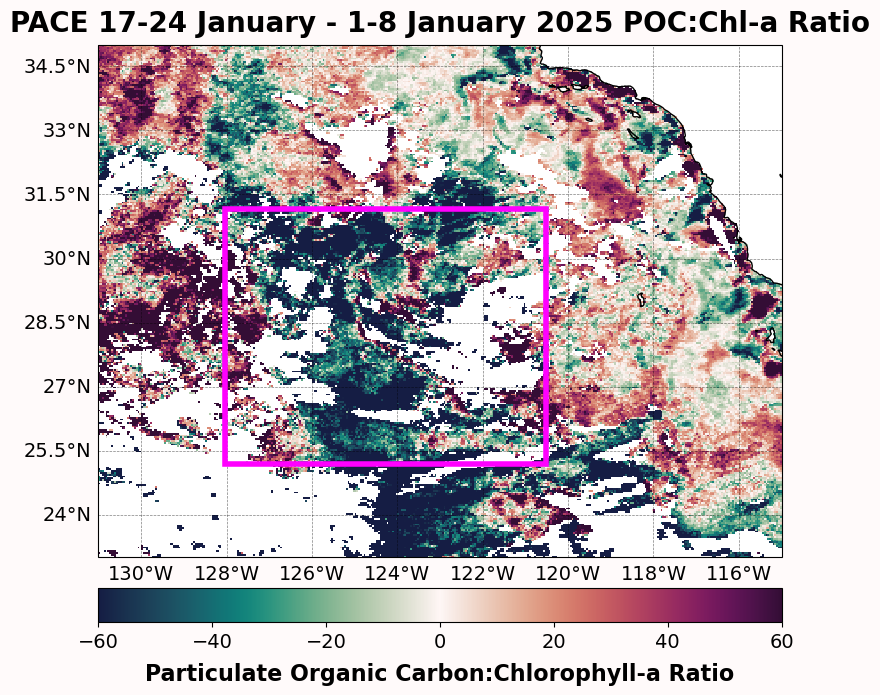

In [37]:
# plot the data
fig = plt.figure(figsize=(8,8), facecolor = 'snow')
ax = plt.axes(projection=ccrs.PlateCarree())

#mesh = subbed.plot(ax=ax, cmap='cmo.diff', vmin=-60, vmax=60, transform=ccrs.PlateCarree(), add_colorbar = False) # for Kd490
mesh = subbed.plot(ax=ax, cmap='cmo.curl', vmin=-60, vmax=60, transform=ccrs.PlateCarree(), add_colorbar = False) # for POC

lon_min, lon_max = -128.045, -120.517 #og
lat_min, lat_max = 25.179, 31.164 #og
width = lon_max - lon_min
height = lat_max - lat_min
ax.add_patch(mpatches.Rectangle(xy=[lon_min, lat_min], width=width, height=height, facecolor='none', edgecolor='magenta', linewidth = 4, zorder = 6, transform=ccrs.PlateCarree()))

ax.coastlines()
#ax.set_ylim([lat_min-5, lat_max+5])
#ax.set_xlim([lon_min-5, lon_max+5])

# set the colorbar
cbar = fig.colorbar(mesh, ax=ax, orientation='horizontal', shrink = 1, pad=0.04)  
cbar.set_label('Particulate Organic Carbon:Chlorophyll-a Ratio', fontsize = 16, fontweight = 'bold', labelpad=8)
cbar.ax.tick_params(labelsize=14)

# edit the gridlines
gl = ax.gridlines(crs = ccrs.PlateCarree(), draw_labels = True, color = 'k', alpha=0.5, linewidth=0.5, linestyle='--')
gl.right_labels = False  
gl.top_labels = False   
gl.xlabel_style = {'size':14}
gl.ylabel_style = {'size':14}
ax.set_extent([-131, -115, 23, 35])

# set the title and save the figure
ax.set_title('PACE 17-24 January - 1-8 January 2025 POC:Chl-a Ratio', fontsize=20, fontweight = 'bold', pad = 10)
plt.tight_layout()
plt.savefig('/home/jovyan/Desktop/figures/PACE/maps/shrunk_poc:Chla ratio 17-24--1-8jan.png', bbox_inches = 'tight', dpi=300)

# Kd490:CHL RATIOS

In [38]:
## Anyway, let's proceed. Alter the time span (tspan) to your frame of interest
tspan = ("2024-12-31", "2025-06-30") # if you just want one day, just do the tspan with the same begin and end date
lon_min, lon_max = -128.045, -120.517 #og
lat_min, lat_max = 25.179, 31.164 #og 
bbox = (lon_min, lat_min, lon_max, lat_max)
shortname_kd = "PACE_OCI_L3M_Kd"
shortname_CHL = "PACE_OCI_L3M_CHL"
clouds = (0,20) #change to (0,100) to see all satellite images (might have clear spot over spot of interest, even if cloudy)

In [39]:
# search for data and open results for kd490
results_kd = earthaccess.search_data(
    short_name=shortname_kd,
    granule_name= '*.8D*4km*',#"*DAY*RRS*4km*.nc", #'*.D*4km*',   #Kd:"*4km*.nc",  #*.8D*4km*", #"*DAY*4km*.nc*" #"*AOP*.nc*"
    temporal=tspan,
    bounding_box=bbox
)
paths_kd = earthaccess.open(results_kd)

# search for data and open results for chla
results_CHL = earthaccess.search_data(
    short_name=shortname_CHL,
    granule_name= '*.8D*4km*',#"*DAY*RRS*4km*.nc", #'*.D*4km*',   #Kd:"*4km*.nc",  #*.8D*4km*", #"*DAY*4km*.nc*" #"*AOP*.nc*"
    temporal=tspan,
    bounding_box=bbox
)
paths_CHL = earthaccess.open(results_CHL)

QUEUEING TASKS | :   0%|          | 0/16 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/16 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/16 [00:00<?, ?it/s]

QUEUEING TASKS | :   0%|          | 0/16 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/16 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/16 [00:00<?, ?it/s]

## Period 1 -- first TOI

In [40]:
# kd490
index=1 #17=13 # set the day you want to look at
datatree_kd = open_datatree(paths_kd[index]) # open the dataset based on that day
dataset_kd = xr.merge(datatree_kd.to_dict().values()) # merge the datatree to a dictionary format
dataset_kd = dataset_kd.set_coords(("lon", "lat")) # set the map based on lat and lon

# CHL
index=1 #17=13 # set the day you want to look at
datatree_CHL = open_datatree(paths_CHL[index]) # open the dataset based on that day
dataset_CHL = xr.merge(datatree_CHL.to_dict().values()) # merge the datatree to a dictionary format
dataset_CHL = dataset_CHL.set_coords(("lon", "lat")) # set the map based on lat and lon
dataset_CHL
dataset_kd

<xarray.Dataset> Size: 3GB
Dimensions:     (lat: 4320, lon: 8640, wavelength: 19, rgb: 3,
                 eightbitcolor: 256)
Coordinates:
  * wavelength  (wavelength) float64 152B 351.0 361.0 385.0 ... 678.0 711.0
  * lat         (lat) float32 17kB 89.98 89.94 89.9 ... -89.9 -89.94 -89.98
  * lon         (lon) float32 35kB -180.0 -179.9 -179.9 ... 179.9 179.9 180.0
Dimensions without coordinates: rgb, eightbitcolor
Data variables:
    Kd          (lat, lon, wavelength) float32 3GB ...
    palette     (rgb, eightbitcolor) uint8 768B ...
Attributes: (12/64)
    product_name:                      PACE_OCI.20250101_20250108.L3m.8D.KD.V...
    instrument:                        OCI
    title:                             OCI Level-3 Standard Mapped Image
    project:                           Ocean Biology Processing Group (NASA/G...
    platform:                          PACE
    source:                            satellite observations from OCI-PACE
    ...                                ...
    identifier_product_doi:            10.5067/PACE/OCI/L3M/KD/3.0
    keywords:                          Earth Science > Oceans > Ocean Optics ...
    keywords_vocabulary:               NASA Global Change Master Directory (G...
    data_bins:                         11117588
    data_minimum:                      0.015999995
    data_maximum:                      6.0000024

In [42]:
# take ratio of the day (ratio1)
ds_ratio_1 = dataset_kd['Kd'].sel(wavelength=490)/dataset_CHL['chlor_a']
ds_ratio_1

<xarray.DataArray (lat: 4320, lon: 8640)> Size: 149MB
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]], dtype=float32)
Coordinates:
    wavelength  float64 8B 490.0
  * lat         (lat) float32 17kB 89.98 89.94 89.9 ... -89.9 -89.94 -89.98
  * lon         (lon) float32 35kB -180.0 -179.9 -179.9 ... 179.9 179.9 180.0

## Period 2 -- second TOI

In [43]:
# POC
index=3 #17=13 # set the day you want to look at
datatree_kd = open_datatree(paths_kd[index]) # open the dataset based on that day
dataset_kd = xr.merge(datatree_kd.to_dict().values()) # merge the datatree to a dictionary format
dataset_kd = dataset_kd.set_coords(("lon", "lat")) # set the map based on lat and lon

# CHL
index=3 #17=13 # set the day you want to look at
datatree_CHL = open_datatree(paths_CHL[index]) # open the dataset based on that day
dataset_CHL = xr.merge(datatree_CHL.to_dict().values()) # merge the datatree to a dictionary format
dataset_CHL = dataset_CHL.set_coords(("lon", "lat")) # set the map based on lat and lon
dataset_CHL
dataset_kd

<xarray.Dataset> Size: 3GB
Dimensions:     (lat: 4320, lon: 8640, wavelength: 19, rgb: 3,
                 eightbitcolor: 256)
Coordinates:
  * wavelength  (wavelength) float64 152B 351.0 361.0 385.0 ... 678.0 711.0
  * lat         (lat) float32 17kB 89.98 89.94 89.9 ... -89.9 -89.94 -89.98
  * lon         (lon) float32 35kB -180.0 -179.9 -179.9 ... 179.9 179.9 180.0
Dimensions without coordinates: rgb, eightbitcolor
Data variables:
    Kd          (lat, lon, wavelength) float32 3GB ...
    palette     (rgb, eightbitcolor) uint8 768B ...
Attributes: (12/64)
    product_name:                      PACE_OCI.20250117_20250124.L3m.8D.KD.V...
    instrument:                        OCI
    title:                             OCI Level-3 Standard Mapped Image
    project:                           Ocean Biology Processing Group (NASA/G...
    platform:                          PACE
    source:                            satellite observations from OCI-PACE
    ...                                ...
    identifier_product_doi:            10.5067/PACE/OCI/L3M/KD/3.0
    keywords:                          Earth Science > Oceans > Ocean Optics ...
    keywords_vocabulary:               NASA Global Change Master Directory (G...
    data_bins:                         13744557
    data_minimum:                      0.015999997
    data_maximum:                      6.000003

In [44]:
# take ratio of the day (ratio2)
ds_ratio_2 = dataset_kd['Kd'].sel(wavelength=490)/dataset_CHL['chlor_a']
ds_ratio_2

<xarray.DataArray (lat: 4320, lon: 8640)> Size: 149MB
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]], dtype=float32)
Coordinates:
    wavelength  float64 8B 490.0
  * lat         (lat) float32 17kB 89.98 89.94 89.9 ... -89.9 -89.94 -89.98
  * lon         (lon) float32 35kB -180.0 -179.9 -179.9 ... 179.9 179.9 180.0

## Subtract Periods

In [45]:
# subtract the periods
subbed = ds_ratio_2 - ds_ratio_1
subbed

<xarray.DataArray (lat: 4320, lon: 8640)> Size: 149MB
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]], dtype=float32)
Coordinates:
    wavelength  float64 8B 490.0
  * lat         (lat) float32 17kB 89.98 89.94 89.9 ... -89.9 -89.94 -89.98
  * lon         (lon) float32 35kB -180.0 -179.9 -179.9 ... 179.9 179.9 180.0

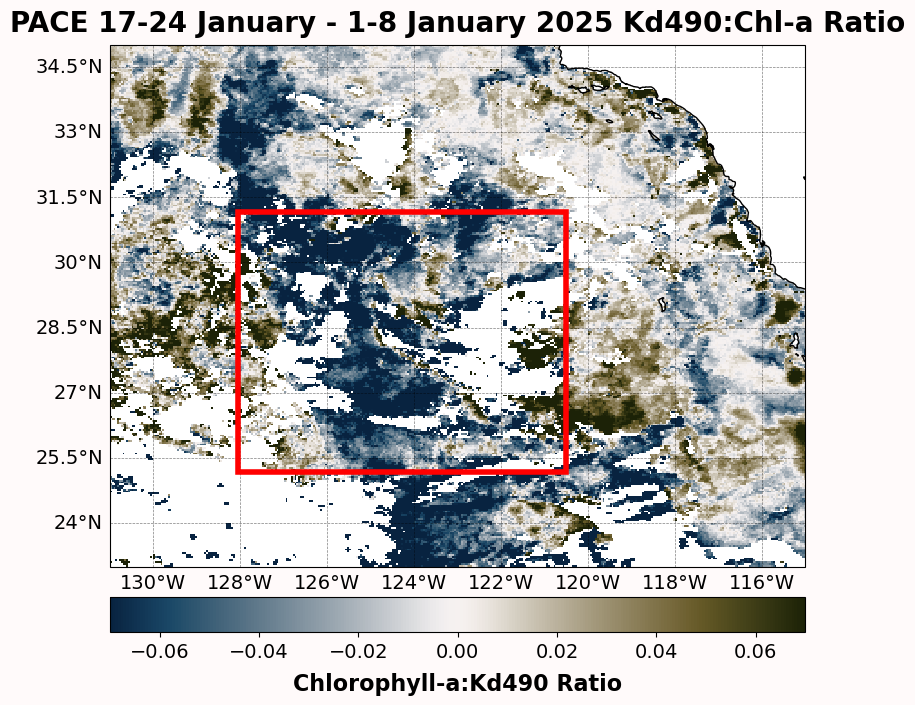

In [50]:
# plot the data
fig = plt.figure(figsize=(8,8), facecolor = 'snow')
ax = plt.axes(projection=ccrs.PlateCarree())

mesh = subbed.plot(ax=ax, cmap='cmo.diff', vmin=-0.07, vmax=0.07, transform=ccrs.PlateCarree(), add_colorbar = False)

lon_min, lon_max = -128.045, -120.517 #og
lat_min, lat_max = 25.179, 31.164 #og
width = lon_max - lon_min
height = lat_max - lat_min
ax.add_patch(mpatches.Rectangle(xy=[lon_min, lat_min], width=width, height=height, facecolor='none', edgecolor='r', linewidth = 4, zorder = 6, transform=ccrs.PlateCarree()))

ax.coastlines()
ax.set_ylim([lat_min-5, lat_max+5])
ax.set_xlim([lon_min-5, lon_max+5])

# set the colorbar
cbar = fig.colorbar(mesh, ax=ax, orientation='horizontal', shrink = 1, pad=0.04)  
cbar.set_label('Chlorophyll-a:Kd490 Ratio', fontsize = 16, fontweight = 'bold', labelpad=8)
cbar.ax.tick_params(labelsize=14)
ax.set_extent([-131, -115, 23, 35])

# edit the gridlines
gl = ax.gridlines(crs = ccrs.PlateCarree(), draw_labels = True, color = 'k', alpha=0.5, linewidth=0.5, linestyle='--')
gl.right_labels = False  
gl.top_labels = False   
gl.xlabel_style = {'size':14}
gl.ylabel_style = {'size':14}

# set the title and save the figure
ax.set_title('PACE 17-24 January - 1-8 January 2025 Kd490:Chl-a Ratio', fontsize=20, fontweight = 'bold', pad = 10)
plt.tight_layout()
plt.savefig('/home/jovyan/Desktop/figures/PACE/maps/shrunk_Kd490:Chla ratio 17-24--1-8jan.png', bbox_inches = 'tight', dpi=300)